# *Global Terrorism Analysis*

Project type - EDA/Regression/Classification/Unsupervised

Nmane : RAVINDRA KUMAR

# OBJECTIVE

The objective of this project is to analyze global terrorism data using exploratory data analysis (EDA) to understand trends, patterns, and distributions of terrorist activities across countries and years. Furthermore, the project applies unsupervised machine learning techniques such as PCA (Principal Component Analysis) and K-Means clustering to reduce data complexity and group countries based on similarities in attack frequency and casualties. The goal is to identify hidden patterns and classify countries into different risk levels, such as low, medium, and high risk, to better understand the global impact of terrorism.

# GitHub Link Click here -> [link](https://github.com/RAVINDRA-robi/Global-Terrorism-Analysis---Exploratory-Data-Analysis-EDA-)



# Problem Statement

The main objective of this project is to perform Exploratory Data Analysis (EDA) on the Global Terrorism Dataset to understand patterns and trends in terrorist activities across the world from 1970 to 2017. The dataset contains detailed information about various incidents, including the year, location, type of attack, weapons used, and the number of casualties.

This project aims to analyze how terrorist activities have changed over time and identify which countries and regions are most affected. It also focuses on understanding the most common types of attacks and weapons used by terrorist groups. In addition, the project examines the impact of these attacks in terms of the number of people killed or injured.

Another important goal is to study the success rate of terrorist attacks to understand how often such incidents are successfully carried out. By exploring these aspects, the project helps in identifying key trends and patterns in the data.

The insights generated from this analysis can be useful for governments and security agencies to improve planning, take preventive measures, and enhance public safety.

# General Guidelines : -

Understand the problem statement and objective of the project clearly before starting the analysis.
Load the dataset properly and check for errors or incorrect data types.
Perform data cleaning by handling missing values and removing unnecessary columns if required.
Use appropriate Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn for analysis and visualization.
Create at least 5 meaningful visualizations to explore patterns and trends in the data.
Write clear observations and insights after each visualization.
Keep the analysis simple, logical, and easy to understand.
Avoid unnecessary complexity and focus on important features of the dataset.
Ensure that the notebook is well-organized with proper headings and explanations.
Summarize the key findings in the conclusion section.

# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# DATA LOADING & UNDERSTAND DATA

In [3]:
df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')
df.head()

/tmp/ipykernel_3801/1883955975.py:1: DtypeWarning: Columns (4,31,33,76,94,96,114,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [4]:
df.tail()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
16576,198207150003,1982,7,15,NaN,0,NaN,69,France,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
16577,198207150004,1982,7,15,NaN,0,NaN,69,France,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,0.0,-9.0,NaN
16578,198207150005,1982,7,15,NaN,0,NaN,98,Italy,8,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
16579,198207150006,1982,7,15,NaN,0,NaN,159,Peru,3,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,0.0,-9.0,NaN
16580,198207160001,1982,7,16,NaN,0,NaN,185,Spain,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16581 entries, 0 to 16580
Columns: 135 entries, eventid to related
dtypes: float64(63), int64(18), object(54)
memory usage: 17.1+ MB


,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,16560
...,...
INT_LOG,1
INT_IDEO,1
INT_MISC,1
INT_ANY,1


# **DATA CLEANING**

In [6]:
df = df[['iyear','country_txt','attacktype1_txt','weaptype1_txt','nkill','nwound']]

# Handle missing values

In [7]:
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)
df.dropna(inplace=True)

# GRAPHS

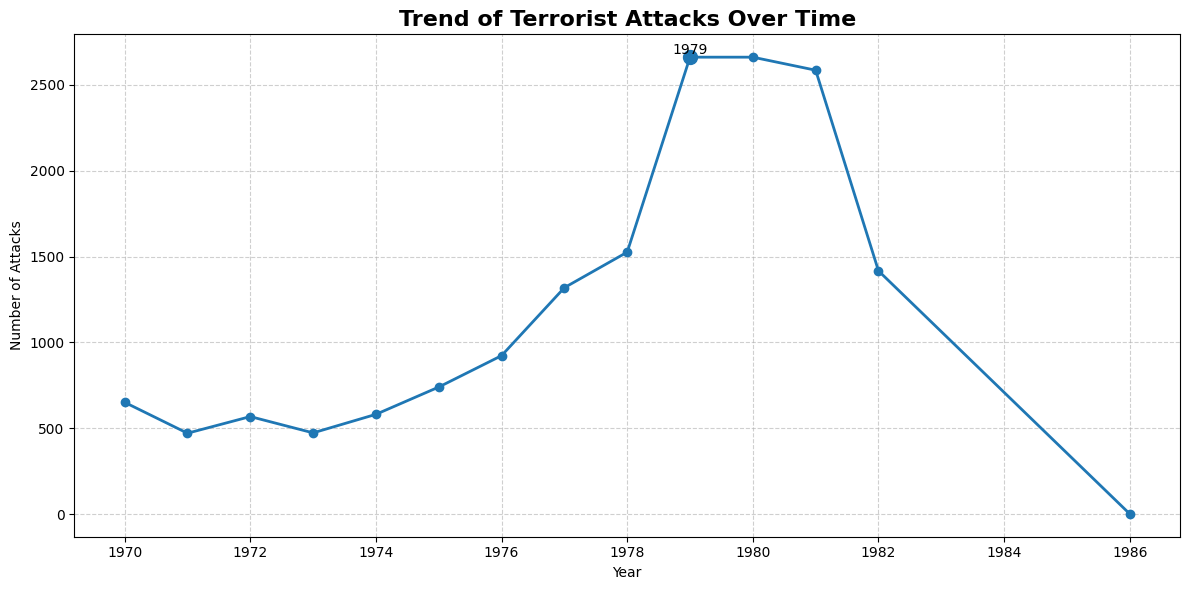

In [32]:
plt.figure(figsize=(12,6))

year_data = df['iyear'].value_counts().sort_index()

plt.plot(year_data.index, year_data.values, marker='o', linewidth=2)

# Highlight max point
max_year = year_data.idxmax()
max_value = year_data.max()

plt.scatter(max_year, max_value, s=100)
plt.text(max_year, max_value, f"{max_year}", ha='center', va='bottom')

plt.title("Trend of Terrorist Attacks Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

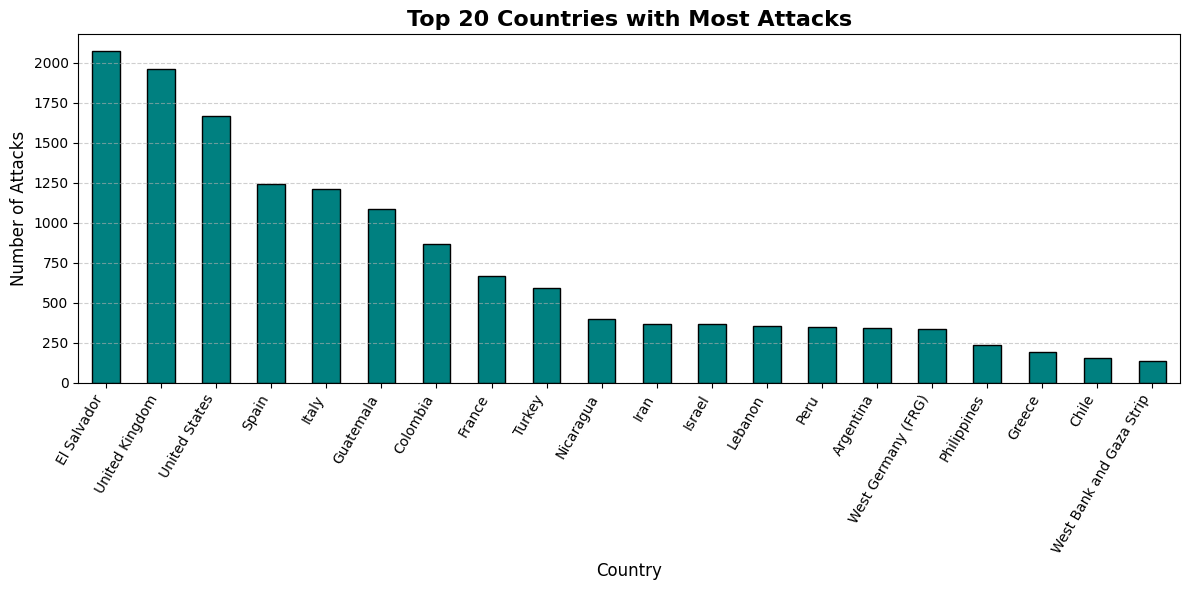

In [29]:
plt.figure(figsize=(12,6))

ax = df['country_txt'].value_counts().head(20).plot(
    kind='bar',
    color='teal',
    edgecolor='black'
)

plt.title("Top 20 Countries with Most Attacks", fontsize=16, fontweight='bold')
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Attacks", fontsize=12)

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

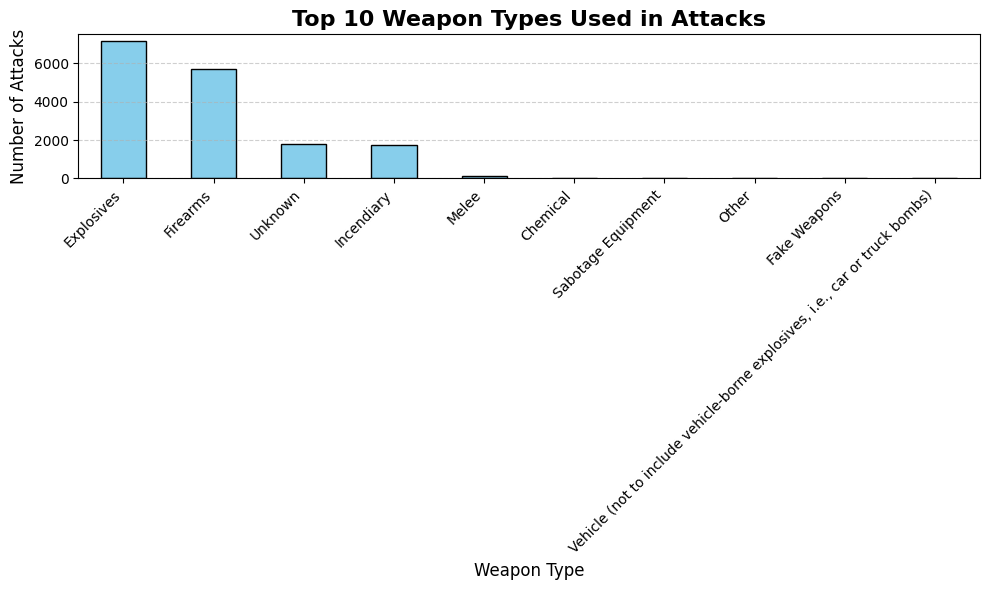

In [28]:
plt.figure(figsize=(10,6))

df['weaptype1_txt'].value_counts().head(10).plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Top 10 Weapon Types Used in Attacks", fontsize=16, fontweight='bold')
plt.xlabel("Weapon Type", fontsize=12)
plt.ylabel("Number of Attacks", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

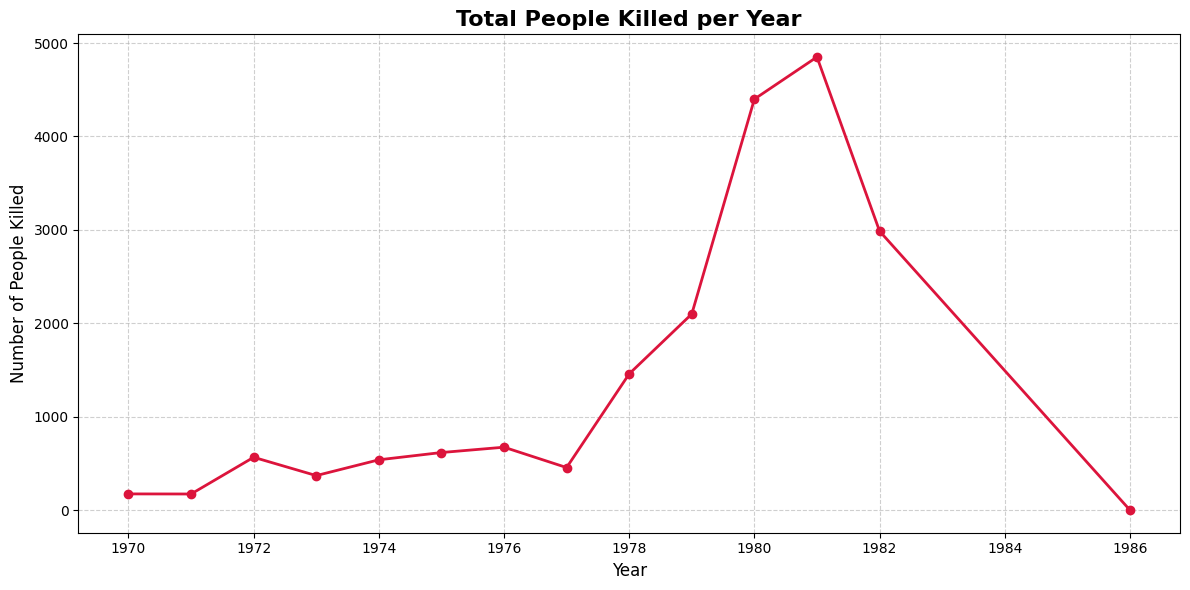

In [36]:
plt.figure(figsize=(12,6))

year_kills = df.groupby('iyear')['nkill'].sum()

plt.plot(
    year_kills.index,
    year_kills.values,
    marker='o',
    linestyle='-',
    linewidth=2,
    color='crimson'
)

plt.title("Total People Killed per Year", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of People Killed", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

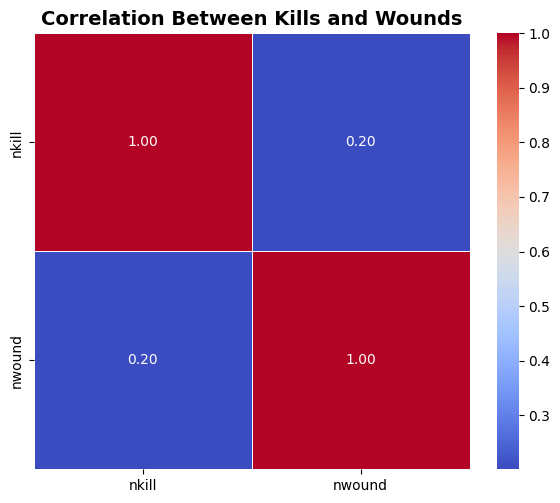

In [35]:
# sns.heatmap(df[['nkill','nwound']].corr(), annot=True)
# plt.show()
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['nkill','nwound']].corr(),
    annot=True,              # show values
    cmap='coolwarm',         # color theme
    fmt='.2f',               # 2 decimal places
    linewidths=0.5,          # borders
    square=True
)

plt.title("Correlation Between Kills and Wounds", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# *PREPARE DATA FOR ML*

In [10]:
attack_count = df['country_txt'].value_counts().reset_index()
attack_count.columns = ['country_txt','attacks']

df_cluster = df.groupby('country_txt')[['nkill','nwound']].sum().reset_index()

df_cluster = df_cluster.merge(attack_count, on='country_txt')

In [20]:
X = df_cluster[['attacks','nkill','nwound']]

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

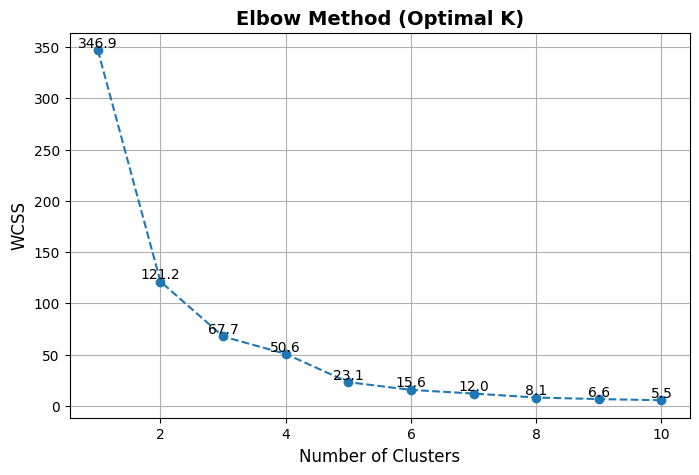

In [25]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o', linestyle='--')

for i, val in enumerate(wcss):
    plt.text(i+1, val, round(val,1), ha='center', va='bottom')

plt.title("Elbow Method (Optimal K)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters", fontsize=12)
plt.ylabel("WCSS", fontsize=12)

plt.grid(True)
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(X_pca)

In [16]:
df_cluster['Risk Level'] = df_cluster['Cluster'].map({
    0:'Low Risk',
    1:'Medium Risk',
    2:'High Risk'
})

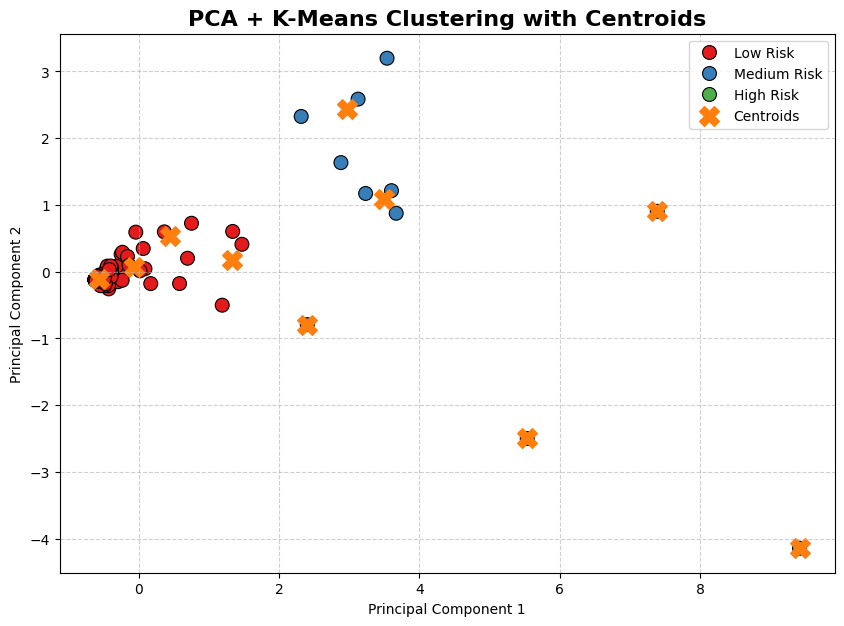

In [27]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df_cluster['Risk Level'],
    palette='Set1',
    s=100,
    edgecolor='black'
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("PCA + K-Means Clustering with Centroids", fontsize=16, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [18]:
df_cluster.sort_values(by='attacks', ascending=False).head(10)

,country_txt,nkill,nwound,attacks,Cluster,Risk Level
34,El Salvador,5007.0,831.0,2075,2,High Risk
112,United Kingdom,1964.0,1490.0,1965,1,Medium Risk
113,United States,212.0,675.0,1668,1,Medium Risk
98,Spain,492.0,886.0,1246,1,Medium Risk
53,Italy,338.0,798.0,1213,1,Medium Risk
41,Guatemala,3236.0,597.0,1087,1,Medium Risk
23,Colombia,1031.0,282.0,869,1,Medium Risk
36,France,90.0,402.0,669,0,Low Risk
109,Turkey,325.0,420.0,591,0,Low Risk
74,Nicaragua,737.0,217.0,402,0,Low Risk


# INSIGHTS

In [39]:
print("\n===== KEY INSIGHTS =====\n")

top_country = df['country_txt'].value_counts().idxmax()
max_year = df['iyear'].value_counts().idxmax()
top_weapon = df['weaptype1_txt'].value_counts().idxmax()
total_killed = df['nkill'].sum()
total_wounded = df['nwound'].sum()
corr = df[['nkill','nwound']].corr().iloc[0,1]
cluster_counts = df_cluster['Risk Level'].value_counts()

print(f"1. Most affected country: {top_country}")
print(f"2. Peak attack year: {max_year}")
print(f"3. Most used weapon: {top_weapon}")
print(f"4. Total killed: {int(total_killed)}")
print(f"5. Total wounded: {int(total_wounded)}")
print(f"6. Correlation (kills vs wounds): {round(corr,2)}")

print("\nCluster Distribution:\n", cluster_counts)


===== KEY INSIGHTS =====

1. Most affected country: El Salvador
2. Peak attack year: 1980
3. Most used weapon: Explosives
4. Total killed: 19367
5. Total wounded: 16290
6. Correlation (kills vs wounds): 0.2

Cluster Distribution:
 Risk Level
Low Risk       113
Medium Risk     10
High Risk        1
Name: count, dtype: int64


# Conclusion

In this project, we analyzed global terrorism data to understand patterns and trends in terrorist activities. Using exploratory data analysis (EDA), we found that some countries are highly affected, while many others have very few incidents. We also observed changes in attacks over the years and identified commonly used weapons and their impact.

After understanding the data, we applied PCA to reduce complexity and K-Means clustering to group countries based on their level of terrorist activity. The model successfully divided countries into different risk levels such as low, medium, and high risk.

Overall, this project helped in identifying important patterns and provided useful insights about global terrorism, which can support better understanding and decision-making.